# Dataset Reader — Schema Evolution

This notebook demonstrates how to read multiple dataset versions while handling schema evolution.

The goal is to:
- read dataset version 1 (v1)
- read dataset version 2 (v2)
- combine both versions into a unified dataset

The notebook also ensures backward compatibility by handling missing columns and enforcing a consistent schema using a schema contract file.

## Step 1 — Import Required Libraries

We import the libraries required for reading datasets and handling schema evolution.

- `os`: manages file paths
- `json`: loads the schema contract file
- `pandas`: reads and manipulates Parquet datasets

In [1]:
import os
import json
import pandas as pd

## Step 2 — Define Project Paths

In this step, we define the paths used throughout the notebook.

These include:
- the root data directory
- the schema contract file
- the Parquet files for v1 and v2

The paths are built dynamically to ensure the notebook works independently of the execution environment.

In [2]:
BASE_DIR = os.path.dirname(os.getcwd())

DATA_DIR = os.path.join(BASE_DIR, "data")
SCHEMA_PATH = os.path.join(BASE_DIR, "schemas", "schema.json")

V1_PATH = os.path.join(DATA_DIR, "v1", "data.parquet")
V2_PATH = os.path.join(DATA_DIR, "v2", "data.parquet")

print("Schema path:", SCHEMA_PATH)
print("v1 path:", V1_PATH)
print("v2 path:", V2_PATH)

Schema path: c:\Users\ASUS\Documents\cloud_computing_project\schemas\schema.json
v1 path: c:\Users\ASUS\Documents\cloud_computing_project\data\v1\data.parquet
v2 path: c:\Users\ASUS\Documents\cloud_computing_project\data\v2\data.parquet


## Step 3 — Load the Schema Contract

In this step, we load the schema contract from the `schema.json` file.

The schema contract defines:
- the expected columns
- the expected data types

This ensures that all dataset versions follow a consistent structure, even when the schema evolves over time.

In [ ]:
with open(SCHEMA_PATH, "r") as f:
    schema = json.load(f)

schema

{'columns': {'ts': 'datetime64[ns]',
  'user_id': 'int64',
  'region': 'object',
  'event_type': 'object',
  'value': 'float64',
  'device_type': 'object'}}

## Step 4 — Extract Expected Columns

In this step, we extract the list of expected columns from the schema contract.

These columns define the unified structure that all dataset versions must follow.

The reader will later use this list to:
- detect missing columns
- enforce schema consistency
- reorder columns correctly

In [4]:
expected_columns = list(schema["columns"].keys())

print("Expected columns:")
print(expected_columns)

Expected columns:
['ts', 'user_id', 'region', 'event_type', 'value', 'device_type']


## Step 5 — Read Dataset Version 1

In this step, we load the first dataset version (`v1`) from its Parquet file.

This dataset represents the original schema before evolution.

We also inspect:
- the dataset shape
- the first rows of the dataset

In [5]:
df_v1 = pd.read_parquet(V1_PATH)

print("v1 shape:", df_v1.shape)

df_v1.head()

v1 shape: (10000, 5)


,ts,user_id,region,event_type,value
0,2026-01-10 05:58:00,543,EU,click,21.115923
1,2026-01-25 21:41:00,996,ASIA,click,5.734924
2,2026-01-23 22:22:00,459,ASIA,click,11.840039
3,2026-01-21 03:56:00,374,EU,click,13.410703
4,2026-01-08 18:49:00,42,EU,view,33.314937


## Step 6 — Read Dataset Version 2

In this step, we load the second dataset version (`v2`) from its Parquet file.

This dataset represents the evolved schema because it includes the new column:

- `device_type`

We inspect the dataset shape and preview the first rows to confirm that v2 was loaded correctly.

In [6]:
df_v2 = pd.read_parquet(V2_PATH)

print("v2 shape:", df_v2.shape)

df_v2.head()

v2 shape: (10000, 6)


,ts,user_id,region,event_type,value,device_type
0,2026-02-19 05:31:00,819,EU,click,8.517889,mobile
1,2026-02-10 12:36:00,906,US,view,21.287385,mobile
2,2026-02-19 20:26:00,926,EU,view,27.030444,mobile
3,2026-02-24 12:18:00,875,EU,click,10.063706,desktop
4,2026-02-04 17:06:00,264,EU,view,33.883013,desktop


## Step 7 — Compare Dataset Schemas

In this step, we compare the schemas of `v1` and `v2`.

The goal is to identify schema evolution between the two dataset versions.

Observation:
- `v1` contains the original schema
- `v2` contains an additional column: `device_type`

This difference must be handled correctly by the reader to ensure backward compatibility.

In [7]:
print("v1 columns:")
print(list(df_v1.columns))

print("\nv2 columns:")
print(list(df_v2.columns))

v1 columns:
['ts', 'user_id', 'region', 'event_type', 'value']

v2 columns:
['ts', 'user_id', 'region', 'event_type', 'value', 'device_type']


## Step 8 — Detect Missing Columns

In this step, we identify which columns are missing from the older dataset version (`v1`).

The expected schema is defined by the schema contract.

Since `v1` was created before schema evolution, it does not contain the `device_type` column.

Detecting missing columns is necessary before unifying dataset versions.

In [8]:
missing_columns_v1 = [
    col for col in expected_columns
    if col not in df_v1.columns
]

print("Missing columns in v1:")
print(missing_columns_v1)

Missing columns in v1:
['device_type']


## Step 9 — Add Missing Columns

In this step, we add the missing columns to the older dataset version (`v1`).

The missing column (`device_type`) is added and filled with `NULL` values.

This is a common strategy used in schema evolution systems:
older datasets are updated logically to match the newest schema without modifying the original historical data.

This ensures backward-compatible reads across dataset versions.

In [9]:
for col in missing_columns_v1:
    df_v1[col] = None

print("Updated v1 columns:")
print(list(df_v1.columns))

Updated v1 columns:
['ts', 'user_id', 'region', 'event_type', 'value', 'device_type']


## Step 10 — Reorder Columns Consistently

In this step, we reorder the columns of both dataset versions using the schema contract.

Even if two datasets contain the same columns, their order may differ.

By enforcing the same column order, we ensure that:
- `v1` and `v2` follow the same output schema
- the datasets can be safely combined
- the reader produces consistent results

In [10]:
df_v1 = df_v1[expected_columns]
df_v2 = df_v2[expected_columns]

print("v1 columns after reordering:")
print(list(df_v1.columns))

print("\nv2 columns after reordering:")
print(list(df_v2.columns))

v1 columns after reordering:
['ts', 'user_id', 'region', 'event_type', 'value', 'device_type']

v2 columns after reordering:
['ts', 'user_id', 'region', 'event_type', 'value', 'device_type']


## Step 11 — Combine Dataset Versions

In this step, we combine `v1` and `v2` into one unified dataset.

Since both versions now share the same schema, they can be safely concatenated.

The combined dataset contains:
- historical data from `v1`
- newer data from `v2`

This demonstrates backward-compatible reading across dataset versions.

In [11]:
df_all = pd.concat([df_v1, df_v2], ignore_index=True)

print("Combined dataset shape:", df_all.shape)

df_all.head()

Combined dataset shape: (20000, 6)


,ts,user_id,region,event_type,value,device_type
0,2026-01-10 05:58:00,543,EU,click,21.115923,None
1,2026-01-25 21:41:00,996,ASIA,click,5.734924,None
2,2026-01-23 22:22:00,459,ASIA,click,11.840039,None
3,2026-01-21 03:56:00,374,EU,click,13.410703,None
4,2026-01-08 18:49:00,42,EU,view,33.314937,None


## Step 12 — Run the Analytics Query

In this step, we execute a simple analytical query on the unified dataset.

The query:
- filters events from the `EU` region
- selects a specific time range
- groups data by `event_type`
- computes:
  - the number of events (`count`)
  - the average value (`avg_value`)

This query is used later for benchmarking and performance evaluation.

In [12]:
df_filtered = df_all[
    (df_all["region"] == "EU") &
    (df_all["ts"] >= "2026-01-01") &
    (df_all["ts"] <= "2026-03-01")
]

result = df_filtered.groupby("event_type").agg(
    count=("event_type", "count"),
    avg_value=("value", "mean")
).reset_index()

result

,event_type,count,avg_value
0,click,6845,30.337813
1,purchase,466,27.934374
2,view,2413,30.504366


## Step 13 — Benchmark Query Execution

In this step, we measure the execution time of the analytical query on different dataset versions.

The query is executed on:
- `v1`
- `v2`
- the combined dataset (`v1 + v2`)

This benchmark helps evaluate the impact of schema evolution and dataset size on query performance.

In [13]:
import time


def run_query(df):
    df_filtered = df[
        (df["region"] == "EU") &
        (df["ts"] >= "2026-01-01") &
        (df["ts"] <= "2026-03-01")
    ]

    result = df_filtered.groupby("event_type").agg(
        count=("event_type", "count"),
        avg_value=("value", "mean")
    ).reset_index()

    return result


# benchmark v1
start = time.time()
run_query(df_v1)
time_v1 = time.time() - start

# benchmark v2
start = time.time()
run_query(df_v2)
time_v2 = time.time() - start

# benchmark combined dataset
start = time.time()
run_query(df_all)
time_all = time.time() - start


print("Execution time (v1):", time_v1)
print("Execution time (v2):", time_v2)
print("Execution time (v1 + v2):", time_all)

Execution time (v1): 0.003117799758911133
Execution time (v2): 0.011026859283447266
Execution time (v1 + v2): 0.0


## Step 14 — Store Benchmark Results

In this step, we store the benchmark results in a structured DataFrame.

The results include:
- the dataset version
- the query execution time in seconds

This makes the benchmark results easier to analyze, export, and visualize later.

In [14]:
results = pd.DataFrame({
    "dataset": ["v1", "v2", "v1+v2"],
    "execution_time_sec": [time_v1, time_v2, time_all]
})

results

,dataset,execution_time_sec
0,v1,0.003118
1,v2,0.011027
2,v1+v2,0.000000


## Step 15 — Export Benchmark Results

In this step, we export the benchmark results to a CSV file.

The results are stored in:

- `results/results.csv`

Saving the results allows:
- reproducibility
- external analysis
- visualization and reporting

In [15]:
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

results_path = os.path.join(RESULTS_DIR, "results.csv")

results.to_csv(results_path, index=False)

print("Results saved to:")
print(results_path)

Results saved to:
c:\Users\ASUS\Documents\cloud_computing_project\results\results.csv


## Step 16 — Visualize Benchmark Results

In this step, we create a simple bar chart to compare query execution times across dataset versions.

The visualization helps illustrate:
- the performance of each dataset version
- the impact of combining multiple dataset versions
- the scalability of the reader under schema evolution

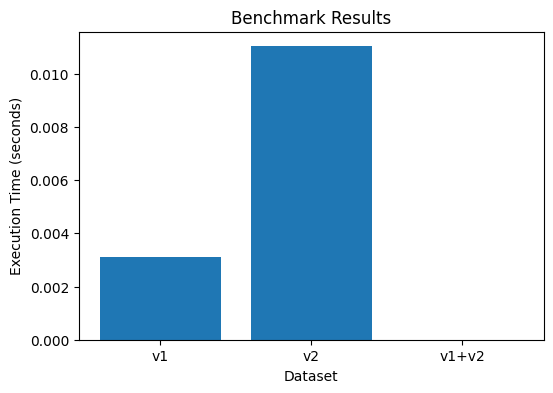

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

plt.bar(results["dataset"], results["execution_time_sec"])

plt.xlabel("Dataset")
plt.ylabel("Execution Time (seconds)")
plt.title("Benchmark Results")

plt.show()